# Read H-Reflex App Data Files (.hrs1 and .hrs2)

This notebook reads and visualizes data from the **H-Reflex Behavior App** binary data files:

- **`.hrs1`**  EMG Characterization stage data (Stage S1): contains trial-initiation monitored signals, binned EMG, and grand means.
- **`.hrs2`** MH Recruitment Curve stage data (Stage S2): contains peri-stimulus trial waveforms with stimulation amplitudes.

Both file types also store raw EMG data blocks (differential, filtered, absolute-valued signals).

The binary format is based on the `FileIO_Helpers` serialization from the `hreflex_txbdc` package.

# Section 1: Binary File Reader Utilities

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import glob as globmod
from IPython.display import display
from helpers import (
    # HRS file readers
    read_hrs1, read_hrs2, find_hrs_files,
    
    # Summary printers
    print_hrs1_summary, print_hrs2_summary,
    # HRS2 plots
    plot_amplitude_distribution, plot_background_emg_views, plot_hrs2_analysis, plot_hrs2_trials,
    split_trials_by_polarity, plot_hm_ratio_summary,
     # Post-hoc global windowing analysis
    analyze_global_background, run_threshold_sweep, plot_threshold_sweep,
    # Constants
    # HRS signal helpers
    detect_stim_onset, get_trial_window, classify_trials,
    # HRS data classes
    EmgCharHeader, EmgCharTrial, EmgDataBlock, EmgTrialsPerHourData, MhRecHeader, MhRecTrial,
    # HRS constants
    SAMPLE_RATE, BIN_DURATION_MS, BIN_SAMPLES, TRIAL_RECORD_MS,
    TRIAL_RECORD_SAMPLES, MS_PER_SAMPLE,
    STIM_ONSET_THRESHOLD, STIM_END_THRESHOLD,
    BLOCK_EMG_DATA, BLOCK_EMG_CHAR_TRIAL, BLOCK_MH_TRIAL, BLOCK_EMG_TRIALS_PER_HOUR,
)

print("Binary reader utilities loaded.")
print(f"  App constants: SAMPLE_RATE={SAMPLE_RATE} Hz | BIN={BIN_DURATION_MS} ms ({BIN_SAMPLES} samples) | TRIAL_RECORD={TRIAL_RECORD_MS} ms")
print(f"  Stim thresholds: onset >= {STIM_ONSET_THRESHOLD} V | end < {STIM_END_THRESHOLD} V")

Binary reader utilities loaded.
  App constants: SAMPLE_RATE=5000.0 Hz | BIN=50 ms (250 samples) | TRIAL_RECORD=100 ms
  Stim thresholds: onset >= 4.5 V | end < 1.9 V


# Section 2: Read and Explore the HRS1 File (EMG Characterization)

# Section 1b: Auto-Detect Recording Files

Set `recording_dir` to the path of your recording folder.  
The `.hrs1` and `.hrs2` files will be found automatically.

In [2]:
# ---- Set your recording directory here ----
# Set to the folder that contains your .hrs1 (and optionally .hrs2) files.
#
# Latest recordings (HRS2 v5, may include background_emg_mean + background_bins):
#   HRPILOT-17_EMG_CHARACTERIZATION_5-12-2026  -- HRS2 v5, 5 kHz, with background_bins
#   D1_5KHZ_HRPILOT16_B_5-11-26               -- HRS2 v5, 5 kHz, background_emg_mean only
#
# New-format HRPILOT recordings (HRS1 includes sample_rate field, HRS2 v4):
#   D1_HRPILOT16_A_5-11-26                    -- 10 kHz, HRS2 v4
#   D1_HRPILOT16_B_5-11-26                    -- 10 kHz, HRS2 v4
#   HRPILOT-16-CONFIGA_RECRUITMENTCURVE_      -- first recruitment curve  (HRS2 v2)
#   HRPILOT-16-CONFIGA_2ND_RECRUITMENTCURVE_  -- second recruitment curve (HRS2 v3, unipolar)
#
# Legacy polarity / hour-test recordings (no sample_rate in HRS1 header):
#   Polarity_Tests/HR-08-POLARITY_TEST_CORRECT   -- electrodes attached correctly
#   Polarity_Tests/HR-08-POLARITY_TEST_FLIPPED_  -- electrodes attached flipped
#   Polarity_Tests/HR-08-HOUR_TEST_              -- HRS1 only (no HRS2 file)

recording_dir = "HRPILOT-17_EMG_CHARACTERIZATION_5-12-2026"
recording_sample_rate = None  # Set to e.g. 5000.0 or 10000.0 to override; None = auto-detect from HRS1 header

hrs1_path, hrs2_path = find_hrs_files(recording_dir)
print(f"Recording directory: {recording_dir}")
print(f"  HRS1 file: {os.path.basename(hrs1_path)}")
if hrs2_path is not None:
    print(f"  HRS2 file: {os.path.basename(hrs2_path)}")
else:
    print("  HRS2 file: not found â HRS2 sections will be skipped")


Recording directory: HRPILOT-17_EMG_CHARACTERIZATION_5-12-2026
  HRS1 file: HRPILOT-17_EMG_CHARACTERIZATION_5-12-2026_20260512T101826.hrs1
  HRS2 file: HRPILOT-17_EMG_CHARACTERIZATION_5-12-2026_20260512T115810.hrs2


In [3]:
# ---- Read the HRS1 file (auto-detected) ----
hrs1_header, hrs1_trials, hrs1_emg_blocks = read_hrs1(hrs1_path)

print(f"=== HRS1 Header ===")
print(f"  File:               {os.path.basename(hrs1_path)}")
print(f"  File version:       {hrs1_header.file_version}")
print(f"  Subject ID:         {hrs1_header.subject_id}")
print(f"  Session datetime:   {hrs1_header.session_datetime}")
print(f"  Stage name:         {hrs1_header.stage_name}")
print(f"  Stage description:  {hrs1_header.stage_description}")
print(f"  Stage type:         {hrs1_header.stage_type}")
print(f"  Trial init uV min:  {hrs1_header.trial_initiation_uv_min}")
print(f"  Trial init uV max:  {hrs1_header.trial_initiation_uv_max}")
print(f"  Trial init phase min ms: {hrs1_header.trial_initiation_phase_min_ms}")
print(f"  Trial init phase max ms: {hrs1_header.trial_initiation_phase_max_ms}")
print(f"  Bin duration ms:    {hrs1_header.bin_duration_ms}")
print(f"  Sample rate:        {hrs1_header.sample_rate} Hz")
tph = hrs1_header.trials_per_hour_data
if tph is not None:
    print(f"  Trials/hr data: centre={tph.sweep_centre_uv:.2f} µV, elapsed={tph.elapsed_hours:.3f} h, {len(tph.window_sizes)} window sizes")
else:
    print("  Trials-per-hour data: not present in file")
print(f"\n  Trials found:       {len(hrs1_trials)}")
print(f"  EMG data blocks:    {len(hrs1_emg_blocks)}")

if len(hrs1_trials) > 0:
    print(f"\n=== First Trial ===")
    t0 = hrs1_trials[0]
    print(f"  End datetime:       {t0.trial_end_datetime}")
    print(f"  Start index:        {t0.trial_start_index}")
    print(f"  Grand mean:         {t0.grand_mean:.4f}")
    print(f"  Bins count:         {len(t0.bins)}")
    print(f"  Monitored signal N: {len(t0.monitored_signal)}")

if len(hrs1_emg_blocks) > 0:
    b0 = hrs1_emg_blocks[0]
    print(f"\n=== First EMG Block ===")
    print(f"  Channel names:      {b0.channel_names}")
    print(f"  Raw channels:       {len(b0.raw_channels)} x {len(b0.raw_channels[0]) if b0.raw_channels else 0} samples")
    print(f"  Diff samples:       {len(b0.diff)}")
    print(f"  Filtered samples:   {len(b0.filtered)}")
    print(f"  Abs samples:        {len(b0.abs_val)}")

=== HRS1 Header ===
  File:               HRPILOT-17_EMG_CHARACTERIZATION_5-12-2026_20260512T101826.hrs1
  File version:       0
  Subject ID:         HRPILOT-17_EMG_CHARACTERIZATION_5-12-2026
  Session datetime:   2026-05-12 10:18:26.190798
  Stage name:         S1
  Stage description:  EMG Characterization
  Stage type:         0
  Trial init uV min:  15.0
  Trial init uV max:  300.0
  Trial init phase min ms: 2200
  Trial init phase max ms: 2700
  Bin duration ms:    50
  Sample rate:        5000.0 Hz
  Trials/hr data: centre=77.44 µV, elapsed=1.434 h, 20 window sizes

  Trials found:       2091
  EMG data blocks:    136239

=== First Trial ===
  End datetime:       2026-05-12 10:18:28.735675
  Start index:        2038184
  Grand mean:         40.5103
  Bins count:         50
  Monitored signal N: 12500

=== First EMG Block ===
  Channel names:      ['CH10', 'CH12', 'ADC1', 'ADC2', 'ADC3', 'ADC4', 'ADC5']
  Raw channels:       7 x 192 samples
  Diff samples:       192
  Filtered sam

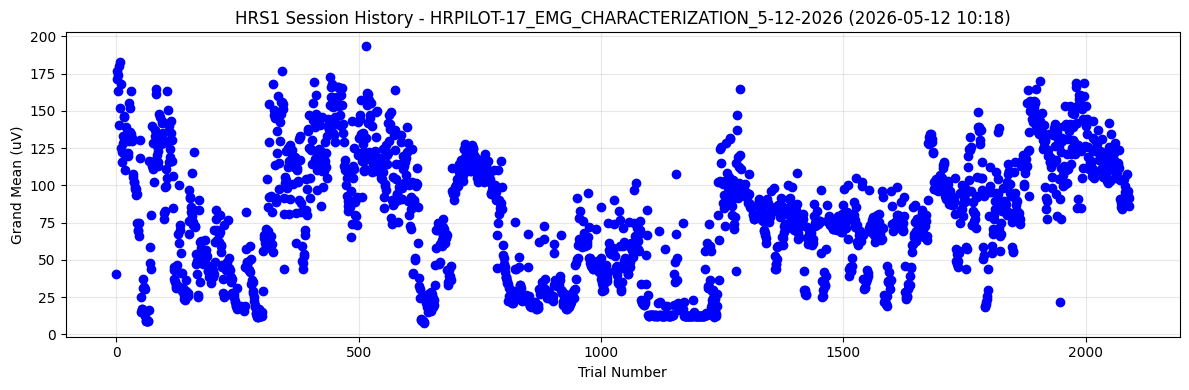

Grand mean range: [7.63, 193.44] uV
Overall mean of grand means: 77.57 uV


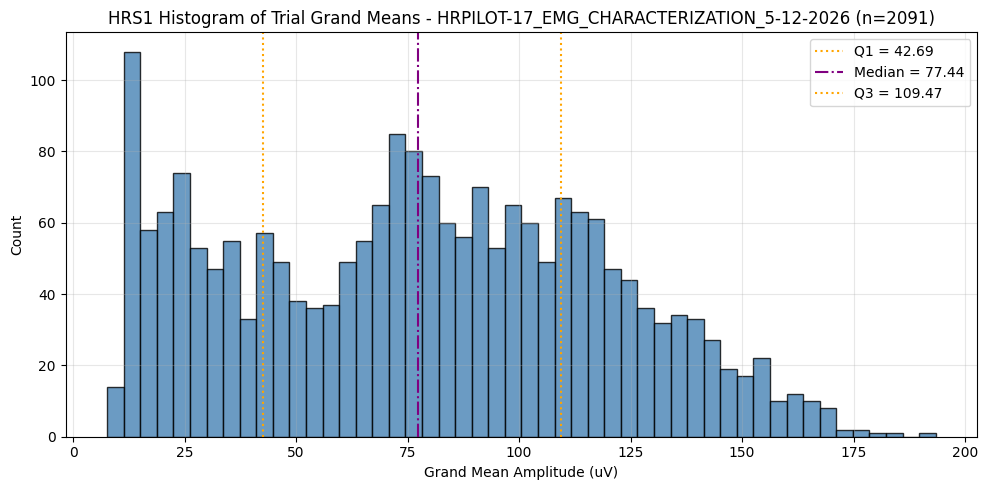

Stats: min=7.63, Q1=42.69, median=77.44, Q3=109.47, max=193.44, std=41.07


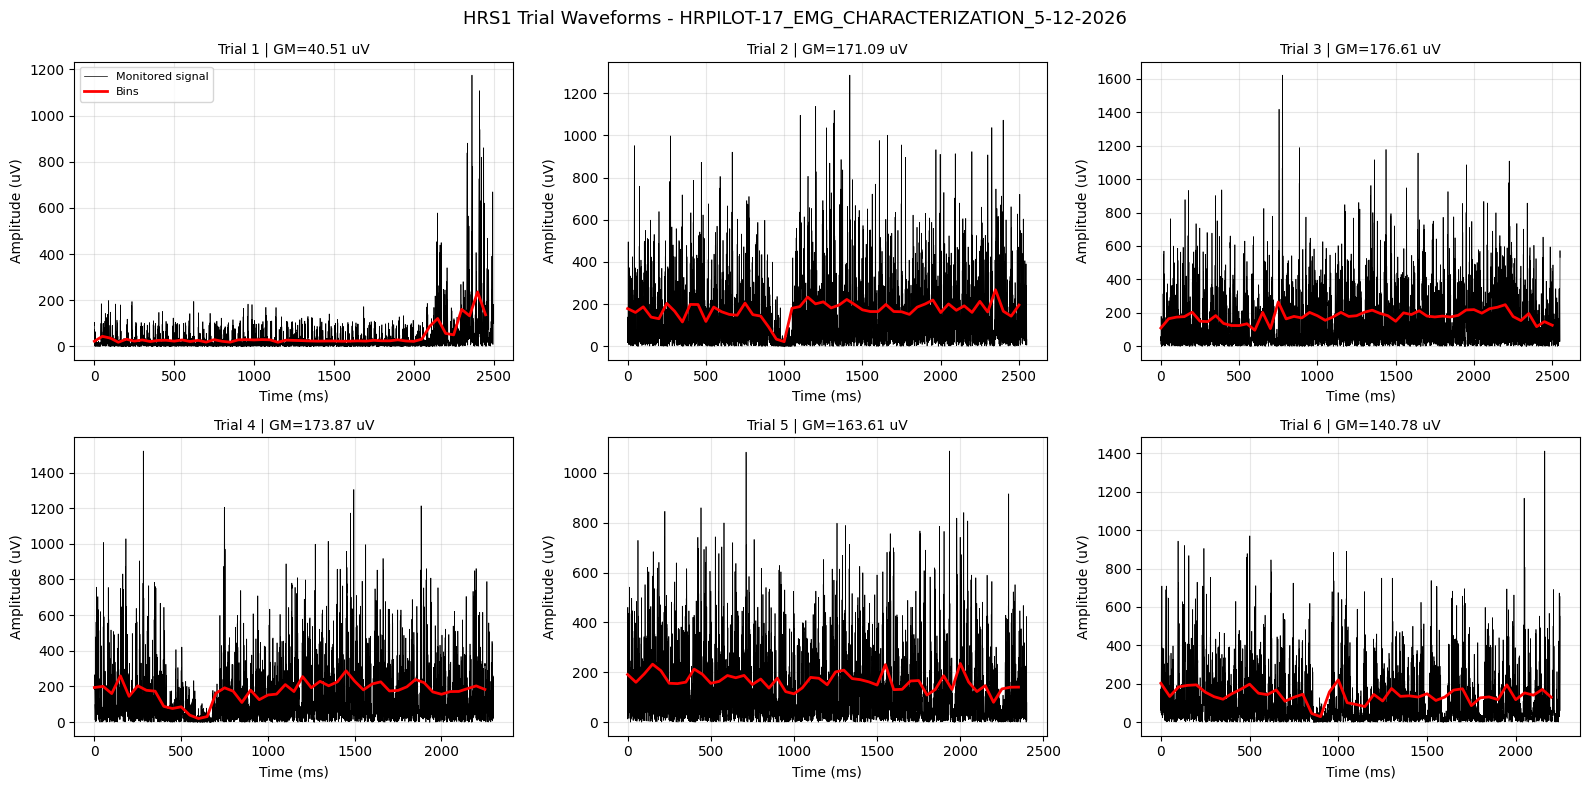

In [4]:
# ---- Plot HRS1: Trial Grand Means (Session History) ----
grand_means = [t.grand_mean for t in hrs1_trials]

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(range(len(grand_means)), grand_means, 'o', color='blue', markersize=6)
ax.set_xlabel('Trial Number')
ax.set_ylabel('Grand Mean (uV)')
ax.set_title(f'HRS1 Session History - {hrs1_header.subject_id} ({hrs1_header.session_datetime:%Y-%m-%d %H:%M})')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Grand mean range: [{min(grand_means):.2f}, {max(grand_means):.2f}] uV")
print(f"Overall mean of grand means: {np.mean(grand_means):.2f} uV")

# ---- Plot HRS1: Histogram of Grand Means ----
gm = np.array(grand_means)

fig, ax = plt.subplots(figsize=(10, 5))
hist_vals, hist_edges, _ = ax.hist(gm, bins=50, color='steelblue', edgecolor='black', alpha=0.8)
#ax.axvline(hrs1_header.trial_initiation_uv_min, color='red', linestyle='--', linewidth=1.5, label=f'Init min = {hrs1_header.trial_initiation_uv_min}')
#ax.axvline(hrs1_header.trial_initiation_uv_max, color='red', linestyle='--', linewidth=1.5, label=f'Init max = {hrs1_header.trial_initiation_uv_max}')

q25, q50, q75 = np.percentile(gm, [25, 50, 75])
ax.axvline(q25, color='orange', linestyle=':', linewidth=1.5, label=f'Q1 = {q25:.2f}')
ax.axvline(q50, color='purple', linestyle='-.', linewidth=1.5, label=f'Median = {q50:.2f}')
ax.axvline(q75, color='orange', linestyle=':', linewidth=1.5, label=f'Q3 = {q75:.2f}')

ax.set_xlabel('Grand Mean Amplitude (uV)')
ax.set_ylabel('Count')
ax.set_title(f'HRS1 Histogram of Trial Grand Means - {hrs1_header.subject_id} (n={len(gm)})')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Stats: min={gm.min():.2f}, Q1={q25:.2f}, median={q50:.2f}, Q3={q75:.2f}, max={gm.max():.2f}, std={gm.std():.2f}")

# ---- Plot HRS1: Individual Trial Waveforms (first 6 trials) ----
n_show = min(6, len(hrs1_trials))

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i in range(n_show):
    ax = axes[i]
    trial = hrs1_trials[i]
    sig = np.array(trial.monitored_signal)
    bins_arr = np.array(trial.bins)
    bin_sample_count = int((SAMPLE_RATE / 1000) * hrs1_header.bin_duration_ms)

    # Time axis in ms
    t_ms = np.arange(len(sig)) / SAMPLE_RATE * 1000.0

    # Plot monitored signal (abs EMG)
    ax.plot(t_ms, sig, color='black', linewidth=0.5, label='Monitored signal')

    # Plot bins
    bin_x = np.arange(len(bins_arr)) * hrs1_header.bin_duration_ms
    ax.plot(bin_x, bins_arr, color='red', linewidth=2, label='Bins')

    ax.set_title(f'Trial {i+1} | GM={trial.grand_mean:.2f} uV', fontsize=10)
    ax.set_xlabel('Time (ms)')
    ax.set_ylabel('Amplitude (uV)')
    ax.grid(True, alpha=0.3)

    if i == 0:
        ax.legend(fontsize=8)

for j in range(n_show, len(axes)):
    axes[j].axis('off')

fig.suptitle(f'HRS1 Trial Waveforms - {hrs1_header.subject_id}', fontsize=13)
plt.tight_layout()
plt.show()


# Section 3: Read and Explore the HRS2 File (MH Recruitment Curve)

In [5]:
# ---- Read the HRS2 file (auto-detected) ----
if hrs2_path is None:
    print("No HRS2 file found â€” skipping HRS2 read.")
    hrs2_header, hrs2_trials, hrs2_emg_blocks = None, [], []
else:
    hrs2_header, hrs2_trials, hrs2_emg_blocks = read_hrs2(hrs2_path)

    if hrs2_header.file_version == 0:
        _fv_desc = "v0: trial_data only"
    elif hrs2_header.file_version == 1:
        _fv_desc = "v1: + ADC sync_data"
    elif hrs2_header.file_version == 2:
        _fv_desc = "v2: + timing/sync debug fields"
    else:
        _fv_desc = "v3: + unipolar_trial_data"

    print(f"=== HRS2 Header ===")
    print(f"  File:               {os.path.basename(hrs2_path)}")
    print(f"  File version:       {hrs2_header.file_version}  ({_fv_desc})")
    print(f"  Subject ID:         {hrs2_header.subject_id}")
    print(f"  Session start time: {hrs2_header.session_start_time}")
    print(f"  Stage name:         {hrs2_header.stage_name}")
    print(f"  Stage description:  {hrs2_header.stage_description}")
    print(f"  Stage type:         {hrs2_header.stage_type}")
    print(f"\n  Trials found:       {len(hrs2_trials)}")
    print(f"  EMG data blocks:    {len(hrs2_emg_blocks)}")

    if len(hrs2_trials) > 0:
        print(f"\n=== First Trial ===")
        t0 = hrs2_trials[0]
        print(f"  Start time:         {t0.start_time}")
        if hrs2_header.file_version >= 3:
            print(f"  Unipolar data len:  {len(t0.unipolar_trial_data)} samples")
        print(f"  Min init threshold: {t0.min_initiation_threshold:.4f} uV")
        print(f"  Max init threshold: {t0.max_initiation_threshold:.4f} uV")
        print(f"  Stim amplitude:     {t0.stimulation_amplitude_ma:.4f} mA")
        print(f"  Trial data:         {len(t0.trial_data)} samples ({len(t0.trial_data)*MS_PER_SAMPLE:.1f} ms)")
        has_sync = len(t0.sync_data) > 1
        print(f"  ADC sync data:      {len(t0.sync_data)} samples {'(present)' if has_sync else '(empty -- file_version 0)'}")

        if hrs2_header.file_version >= 2:
            _onset_desc = 'detected' if t0.onset_detected else 'fallback -- no threshold crossing'
            print(f"\n  --- File Version 2 Timing / Sync Fields ---")
            print(f"  trigger_wall_time_ms:               {t0.trigger_wall_time_ms}")
            print(f"  onset_sample_index:                 {t0.onset_sample_index}  ({_onset_desc})")
            print(f"  onset_detected:                     {bool(t0.onset_detected)}")
            print(f"  stim_end_sample_index:              {t0.stim_end_sample_index}")
            print(f"  stim_duration_samples:              {t0.stim_duration_samples}")
            print(f"  stim_duration_ms:                   {t0.stim_duration_ms:.3f} ms")
            print(f"  sync_peak_voltage:                  {t0.sync_peak_voltage:.4f} V  (threshold = {STIM_ONSET_THRESHOLD} V)")
            print(f"  n_pre_trigger_frames_discarded:     {t0.n_pre_trigger_frames_discarded}")
            print(f"  first_post_trigger_frame_sample_id: {t0.first_post_trigger_frame_sample_id}")
            print(f"  frame_received_timestamps_ms:       {len(t0.frame_received_timestamps_ms)} entries")

        stim_amps = [t.stimulation_amplitude_ma for t in hrs2_trials]
        unique_amps = sorted(set([round(a, 2) for a in stim_amps]))
        print(f"\n=== Stimulation Summary ===")
        print(f"  Unique amplitudes (mA): {unique_amps}")
        print(f"  Total trials:           {len(hrs2_trials)}")
        for amp in unique_amps:
            count = sum(1 for a in stim_amps if round(a, 2) == amp)
            print(f"    {amp:.2f} mA : {count} trial(s)")
    else:
        print("\nNo trials found.")

    if len(hrs2_emg_blocks) > 0:
        b0 = hrs2_emg_blocks[0]
        print(f"\n=== First EMG Block ===")
        print(f"  Channel names:  {b0.channel_names}")
        print(f"  Raw channels:   {len(b0.raw_channels)} x {len(b0.raw_channels[0]) if b0.raw_channels else 0} samples")
        print(f"  Diff samples:   {len(b0.diff)}")

=== HRS2 Header ===
  File:               HRPILOT-17_EMG_CHARACTERIZATION_5-12-2026_20260512T115810.hrs2
  File version:       5  (v3: + unipolar_trial_data)
  Subject ID:         HRPILOT-17_EMG_CHARACTERIZATION_5-12-2026
  Session start time: 2026-05-12 11:58:29.701284
  Stage name:         S2
  Stage description:  Mh Recruitment Curve
  Stage type:         1

  Trials found:       736
  EMG data blocks:    62206

=== First Trial ===
  Start time:         2026-05-12 11:58:30.223209
  Unipolar data len:  2927 samples
  Min init threshold: 7.6322 uV
  Max init threshold: 193.4399 uV
  Stim amplitude:     0.4000 mA
  Trial data:         2927 samples (585.4 ms)
  ADC sync data:      2927 samples (present)

  --- File Version 2 Timing / Sync Fields ---
  trigger_wall_time_ms:               1778605110223
  onset_sample_index:                 476  (detected)
  onset_detected:                     True
  stim_end_sample_index:              479
  stim_duration_samples:              3
  stim_dur

# Section 3a: Initiation Thresholds Summary

Displays the EMG amplitude thresholds and timing windows used to initiate trials in both stages:

- **S1 (EMG Characterization):** fixed thresholds stored in the file header â€” the grand mean of binned absolute EMG must fall between `trial_initiation_uv_min` and `trial_initiation_uv_max`.
- **S2 (MH Recruitment Curve):** per-trial thresholds stored with each trial â€” the app derives them from the S1 histogram percentiles, so they may vary if the experimenter re-ran the calculation.

In [6]:
# ---- Initiation Thresholds Summary ----

print("=" * 62)
print("  INITIATION THRESHOLDS SUMMARY")
print("=" * 62)

# --- S1: EMG Characterization (values stored in HRS1 header) ---
print("\nS1 EMG Characterization Stage")
print(f"  Lower bound : {hrs1_header.trial_initiation_uv_min:.2f} µV")
print(f"  Upper bound : {hrs1_header.trial_initiation_uv_max:.2f} µV")
print(f"  (A trial is accepted when the grand mean of binned |EMG| falls within this range)")
print(f"  Monitoring window : {hrs1_header.trial_initiation_phase_min_ms}–{hrs1_header.trial_initiation_phase_max_ms} ms  |  Bin duration : {hrs1_header.bin_duration_ms} ms")

# --- S2: MH Recruitment Curve (lower/upper bounds stored per trial in HRS2) ---
print("\nS2 MH Recruitment Curve Stage")
if hrs2_header is None or len(hrs2_trials) == 0:
    print("  No HRS2 file / no trials found.")
else:
    s2_mins = [t.min_initiation_threshold for t in hrs2_trials]
    s2_maxs = [t.max_initiation_threshold for t in hrs2_trials]
    all_same = (len(set(round(v, 4) for v in s2_mins)) == 1 and
                len(set(round(v, 4) for v in s2_maxs)) == 1)
    if all_same:
        print(f"  Lower bound : {s2_mins[0]:.4f} µV  (constant across all {len(hrs2_trials)} trials)")
        print(f"  Upper bound : {s2_maxs[0]:.4f} µV  (constant across all {len(hrs2_trials)} trials)")
    else:
        print(f"  Thresholds varied across {len(hrs2_trials)} trials:")
        print(f"  {'Trial':>6}  {'Lower bound (µV)':>18}  {'Upper bound (µV)':>18}")
        for i, (mn, mx) in enumerate(zip(s2_mins, s2_maxs)):
            print(f"  {i + 1:>6}  {mn:>18.4f}  {mx:>18.4f}")

print("\n" + "=" * 62)

  INITIATION THRESHOLDS SUMMARY

S1 EMG Characterization Stage
  Lower bound : 15.00 µV
  Upper bound : 300.00 µV
  (A trial is accepted when the grand mean of binned |EMG| falls within this range)
  Monitoring window : 2200–2700 ms  |  Bin duration : 50 ms

S2 MH Recruitment Curve Stage
  Thresholds varied across 736 trials:
   Trial    Lower bound (µV)    Upper bound (µV)
       1              7.6322            193.4399
       2              7.6322            193.4399
       3              7.6322            193.4399
       4              7.6322            193.4399
       5              7.6322            193.4399
       6              7.6322            193.4399
       7              7.6322            193.4399
       8              7.6322            193.4399
       9              7.6322            193.4399
      10              7.6322            193.4399
      11              7.6322            193.4399
      12              7.6322            193.4399
      13              7.6322       

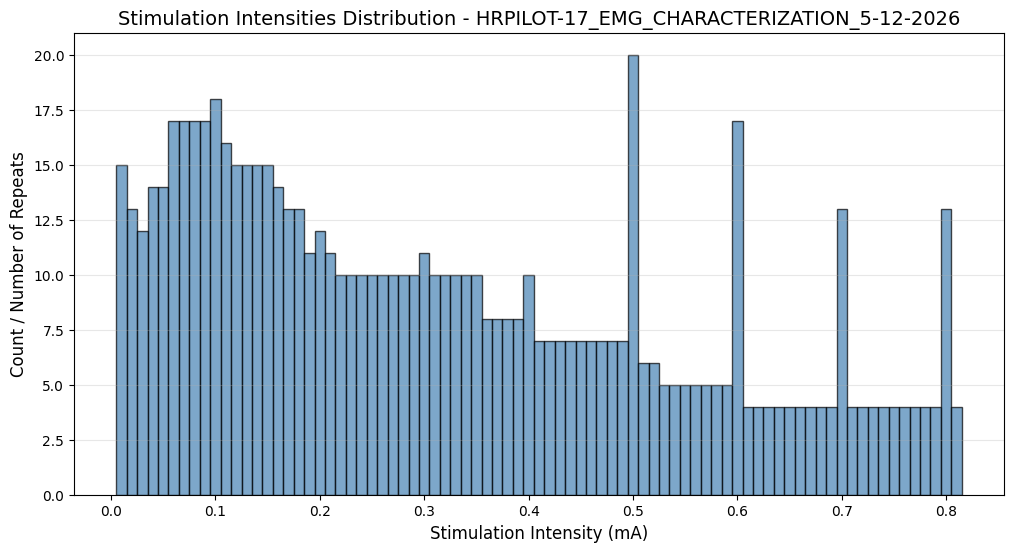

In [7]:
# ---- Histogram of Stimulation Intensities ----
if hrs2_trials:
    from collections import defaultdict
    
    # Create mapping of amplitude to count
    amp_to_trials = defaultdict(list)
    for i, t in enumerate(hrs2_trials):
        amp_to_trials[round(t.stimulation_amplitude_ma, 2)].append(i)
    
    # Extract amplitudes and their counts
    amplitudes = sorted(amp_to_trials.keys())
    counts = [len(amp_to_trials[amp]) for amp in amplitudes]
    
    # Create histogram plot
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.bar(amplitudes, counts, width=0.01, color='steelblue', edgecolor='black', alpha=0.7)
    ax.set_xlabel('Stimulation Intensity (mA)', fontsize=12)
    ax.set_ylabel('Count / Number of Repeats', fontsize=12)
    ax.set_title(f'Stimulation Intensities Distribution - {hrs2_header.subject_id}', fontsize=14)
    ax.grid(True, alpha=0.3, axis='y')
    

In [8]:
shared_ylim = (-1500, 1500)  # Set a common y-axis limit for all trial plots

In [9]:
#  Configuration 
PRE_PLOT_MS  = 2   # ms before stim onset to display
POST_PLOT_MS = 15  # ms after  stim onset to display
N_PER_PAGE   = 6   # trials shown per page (2 rows x 3 cols)

# M/H wave window constants (ms relative to stim onset)
M_WAVE_START_MS = 2.5   
M_WAVE_END_MS   = 4.5
H_WAVE_START_MS = 6
H_WAVE_END_MS   = 9

PRE_AVG_MS  = 2   # ms before stim onset
POST_AVG_MS = 15  # ms after  stim onset
N_PER_PAGE  = 6   # amplitude groups per page (2 rows x 3 cols)


Loaded 81 amplitude groups across 14 page(s).
Double-click a subplot to zoom in. Ctrl-click to select multiple signals.


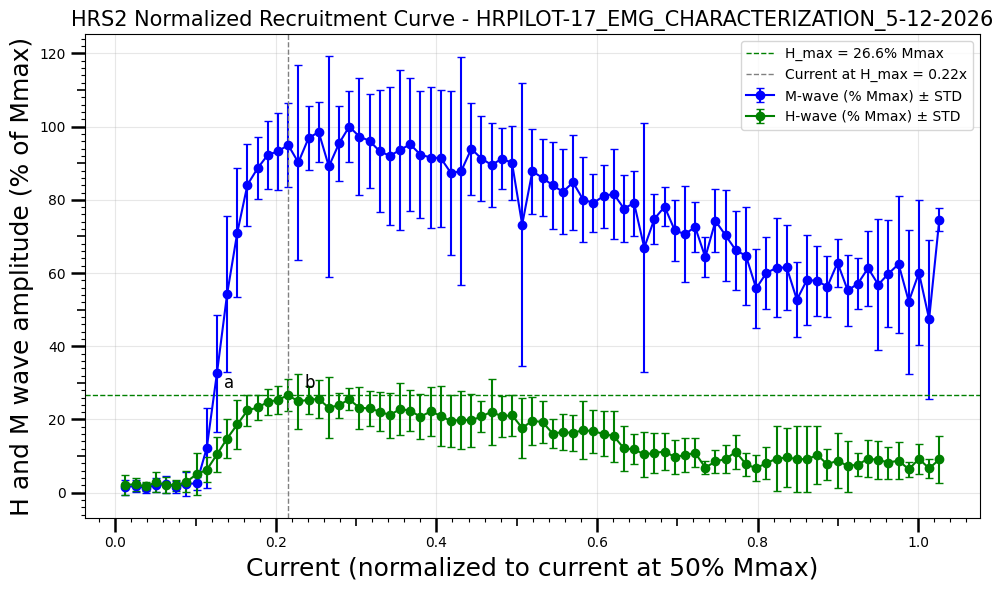

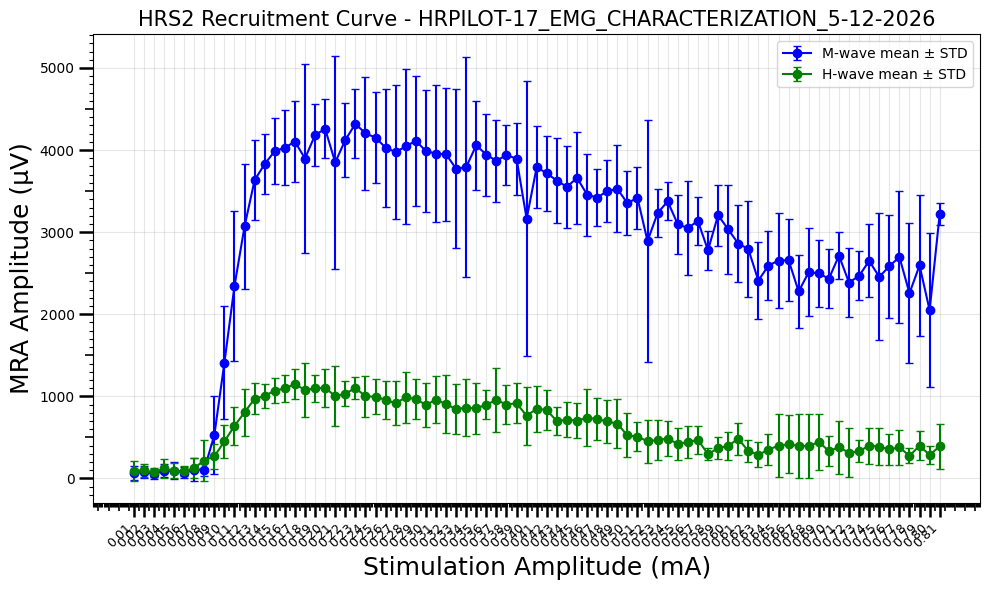

M_max = 4319.92 µV
H_max = 1150.29 µV (26.6% of M_max)
Current at 50% M_max = 0.79 mA
Current at H_max = 0.17 mA (0.22x normalized)


In [ ]:
# ---- HRS2 Analysis: Interactive Averaged Waveforms + Recruitment Curve ----
plot_hrs2_analysis(
    hrs2_trials, hrs2_header,
    pre_avg_ms=PRE_AVG_MS, post_avg_ms=POST_AVG_MS,
    n_per_page=N_PER_PAGE,
    m_start_ms=M_WAVE_START_MS, m_end_ms=M_WAVE_END_MS,
    h_start_ms=H_WAVE_START_MS, h_end_ms=H_WAVE_END_MS,
    sample_rate=recording_sample_rate or hrs1_header.sample_rate,
)

In [ ]:
# ---- HRS2 Trial Viewer: Interactive Per-Trial Grid + Zoom ----
plot_hrs2_trials(
    hrs2_trials, hrs2_header,
    pre_plot_ms=PRE_PLOT_MS, post_plot_ms=POST_PLOT_MS,
    n_per_page=N_PER_PAGE,
    m_start_ms=M_WAVE_START_MS, m_end_ms=M_WAVE_END_MS,
    h_start_ms=H_WAVE_START_MS, h_end_ms=H_WAVE_END_MS,
    sample_rate=recording_sample_rate or hrs1_header.sample_rate,
)

# Section 3c: H:M Ratio Summary

Box plot and histogram of H:M ratio for each stimulation polarity group.
If both normal and reversed polarities were used in this session, each group is analysed separately.

In [ ]:
# ---- Stim polarity split ----
trials_by_polarity = split_trials_by_polarity(hrs2_trials)

# ---- H:M Ratio Summary: box plot + histogram ----
plot_hm_ratio_summary(
    trials_by_polarity, hrs2_header,
    m_start_ms=M_WAVE_START_MS, m_end_ms=M_WAVE_END_MS,
    h_start_ms=H_WAVE_START_MS, h_end_ms=H_WAVE_END_MS,
    sample_rate=recording_sample_rate or hrs1_header.sample_rate,
    pre_ms=PRE_PLOT_MS, post_ms=POST_PLOT_MS,
)

In [12]:
'''
# ---- Failed Trial Detector ----
# classify_trials() is defined in helpers.py.
# For file_version >= 2 it uses pre-computed fields (onset_detected, sync_peak_voltage, etc.)
# stored directly in each trial object; for older files it re-derives them from sync_data.

trial_report = classify_trials(hrs2_trials, file_version=hrs2_header.file_version)

failed = [r for r in trial_report if r['failed']]
passed = [r for r in trial_report if not r['failed']]

print(f"File version : {hrs2_header.file_version}  "
      f"({'pre-computed fields used' if hrs2_header.file_version >= 2 else 'fields derived from sync_data'})")
print(f"Total trials : {len(trial_report)}")
print(f"Passed       : {len(passed)}")
print(f"Failed       : {len(failed)}")
print()

if failed:
    v2 = hrs2_header.file_version >= 2
    hdr = (f"{'Trial':>6}  {'Amp':>6}  {'ADC peak':>9}  {'Noise std':>10}  "
           f"{'Stim dur ms':>11}  {'Discarded':>9}  Reason")
    print(hdr)
    print("-" * len(hdr))
    for r in failed:
        reason = ("no sync data" if not r['has_sync']
                  else f"ADC peak {r['adc_peak']:.3f} V < {STIM_ONSET_THRESHOLD} V threshold")
        dur_str  = f"{r['stim_duration_ms']:.2f}" if r['stim_duration_ms'] else "â€”"
        disc_str = str(r['n_pre_trigger_frames_discarded']) if v2 else "n/a"
        print(f"{r['idx']+1:>6}  {r['amp_ma']:>6.2f}  {r['adc_peak']:>9.3f}  "
              f"{r['adc_noise_std']:>10.4f}  {dur_str:>11}  {disc_str:>9}  {reason}")
else:
    print("No failed trials detected.")



# ---- Debug: Â±10 s context window from continuous data around trial onset ----
# Shows EMG (filtered) and ADC sync line (abs) pulled from hrs2_emg_blocks.
# Default TRIAL_IDX is the first failed trial; change to inspect any trial.

import importlib, helpers as _helpers_mod
importlib.reload(_helpers_mod)
from helpers import get_trial_context_window

# Default to first failed trial if any exist; otherwise use index 1
TRIAL_IDX = (failed[0]['idx'] + 1) if failed else 1  # 1-indexed
_tr = hrs2_trials[TRIAL_IDX - 1]

_ctx = get_trial_context_window(_tr, hrs2_emg_blocks, pre_s=10.0, post_s=10.0)

if _ctx is None:
    print(f"Trial {TRIAL_IDX}: cannot locate onset in continuous data.\n"
          f"  first_post_trigger_frame_sample_id = {_tr.first_post_trigger_frame_sample_id}\n"
          f"  onset_sample_index                 = {_tr.onset_sample_index}\n"
          f"  trigger_wall_time_ms               = {_tr.trigger_wall_time_ms}")
else:
    _t_s, _emg_ctx, _onset_i, _adc_ctx = _ctx
    _adc_abs = np.abs(_adc_ctx) if _adc_ctx is not None else None

    print(f"Trial {TRIAL_IDX} | Stim: {_tr.stimulation_amplitude_ma:.2f} mA  |  onset_detected={getattr(_tr, 'onset_detected', '?')}")
    print(f"  Context window : {_t_s[0]:.1f} s â†’ {_t_s[-1]:.1f} s  ({len(_t_s)} samples)")
    print(f"  EMG range      : [{_emg_ctx.min():.2f}, {_emg_ctx.max():.2f}] ÂµV")
    print(f"  onset @ index  : {_onset_i}  (t = {_t_s[_onset_i]:.4f} s)")

    # Find the first pulse in |ADC| that crosses the threshold AFTER the sensed onset â”€â”€
    _pulse_i   = None
    _pulse_t_s = None
    _delay_ms  = None
    if _adc_abs is not None:
        _post = _adc_abs[_onset_i:]
        _cands = np.where(_post >= STIM_ONSET_THRESHOLD)[0]
        if len(_cands) > 0:
            _pulse_i   = _onset_i + int(_cands[0])
            _pulse_t_s = float(_t_s[_pulse_i])
            _delay_ms  = _pulse_t_s * 1000.0  # t_s is already re: onset, so delay = pulse_t_s

    if _adc_abs is not None:
        print(f"  ADC range (abs): [{_adc_abs.min():.3f}, {_adc_abs.max():.3f}] V  "
              f"(peak = {_adc_abs.max():.3f} V vs threshold {STIM_ONSET_THRESHOLD} V)")
    if _pulse_i is not None:
        print(f"\n  â”€â”€ Post-onset pulse â”€â”€")
        print(f"     Sample index in window : {_pulse_i}")
        print(f"     Time re: onset         : {_pulse_t_s:.4f} s  ({_pulse_t_s*1000:.2f} ms)")
        print(f"     Delay from sensed onset: {_delay_ms:.2f} ms")
    else:
        print(f"\n  No ADC pulse >= {STIM_ONSET_THRESHOLD} V found after sensed onset.")

    fig, (ax_emg, ax_adc) = plt.subplots(2, 1, figsize=(16, 6), sharex=True,
                                          gridspec_kw={'height_ratios': [2, 1]})

    # --- EMG subplot ---
    ax_emg.plot(_t_s, _emg_ctx, color='black', linewidth=0.5, label='Filtered EMG')
    ax_emg.axvline(0, color='red', linestyle='--', linewidth=1.2, label='Sensed onset (t = 0)')
    if _pulse_t_s is not None:
        ax_emg.axvline(_pulse_t_s, color='orange', linestyle=':', linewidth=1.2,
                       label=f'ADC pulse (+{_delay_ms:.1f} ms)')
    ax_emg.axvspan(-10, 0, color='blue',  alpha=0.04, label='Pre-onset 10 s')
    ax_emg.axvspan(  0, 10, color='green', alpha=0.04, label='Post-onset 10 s')
    ax_emg.set_ylabel('EMG (ÂµV)')
    ax_emg.set_title(
        f"Trial {TRIAL_IDX}  |  {_tr.stimulation_amplitude_ma:.2f} mA  |  "
        f"onset_detected={getattr(_tr, 'onset_detected', '?')}  |  "
        f"Â±10 s continuous context  â€”  {hrs2_header.subject_id}"
    )
    ax_emg.legend(fontsize=8, loc='upper right')
    ax_emg.grid(True, alpha=0.3)

    # --- ADC sync subplot (abs) ---
    if _adc_abs is not None:
        ax_adc.plot(_t_s, _adc_abs, color='green', linewidth=0.6, label='|ADC sync| (V)')
        ax_adc.axhline(STIM_ONSET_THRESHOLD, color='red', linestyle='--', linewidth=1.0,
                       label=f'Onset threshold ({STIM_ONSET_THRESHOLD} V)')
        ax_adc.axvline(0, color='red', linestyle='--', linewidth=1.2, label='Sensed onset (t = 0)')
        if _pulse_t_s is not None:
            ax_adc.axvline(_pulse_t_s, color='orange', linestyle=':', linewidth=1.2,
                           label=f'First post-onset pulse (t = {_pulse_t_s*1000:.2f} ms, delay = {_delay_ms:.1f} ms)')
            ax_adc.annotate(f'+{_delay_ms:.1f} ms',
                            xy=(_pulse_t_s, STIM_ONSET_THRESHOLD),
                            xytext=(_pulse_t_s + 0.2, STIM_ONSET_THRESHOLD * 1.15),
                            fontsize=8, color='orange',
                            arrowprops=dict(arrowstyle='->', color='orange', lw=1.0))
        ax_adc.set_ylabel('|ADC| (V)')
        ax_adc.legend(fontsize=8, loc='upper right')
        ax_adc.grid(True, alpha=0.3)
    else:
        ax_adc.text(0.5, 0.5, 'ADC channel not available in continuous blocks',
                    transform=ax_adc.transAxes, ha='center', va='center', color='gray')

    ax_adc.set_xlabel('Time re: onset (s)')
    plt.tight_layout()
    plt.show()
    '''


'\n# ---- Failed Trial Detector ----\n# classify_trials() is defined in helpers.py.\n# For file_version >= 2 it uses pre-computed fields (onset_detected, sync_peak_voltage, etc.)\n# stored directly in each trial object; for older files it re-derives them from sync_data.\n\ntrial_report = classify_trials(hrs2_trials, file_version=hrs2_header.file_version)\n\nfailed = [r for r in trial_report if r[\'failed\']]\npassed = [r for r in trial_report if not r[\'failed\']]\n\nprint(f"File version : {hrs2_header.file_version}  "\n      f"({\'pre-computed fields used\' if hrs2_header.file_version >= 2 else \'fields derived from sync_data\'})")\nprint(f"Total trials : {len(trial_report)}")\nprint(f"Passed       : {len(passed)}")\nprint(f"Failed       : {len(failed)}")\nprint()\n\nif failed:\n    v2 = hrs2_header.file_version >= 2\n    hdr = (f"{\'Trial\':>6}  {\'Amp\':>6}  {\'ADC peak\':>9}  {\'Noise std\':>10}  "\n           f"{\'Stim dur ms\':>11}  {\'Discarded\':>9}  Reason")\n    print(hdr)\n 

In [13]:
'''
# ---- Plot HRS2: Averaged Waveforms Grouped by Stimulation Amplitude ----
# Trials are aligned to detected stim onset via get_trial_window() before averaging.
# M- and H-wave windows are shaded on every plot.
# A red overlay marks the stimulation period (onset to end).
from collections import defaultdict

PRE_AVG_MS  = 2   # ms before stim onset
POST_AVG_MS = 15  # ms after  stim onset

M_WAVE_START_MS = 2.5
M_WAVE_END_MS   = 4.0
H_WAVE_START_MS = 6.0
H_WAVE_END_MS   = 10.0

if len(hrs2_trials) > 0:
    # Build onset-aligned windows grouped by amplitude, capturing stim_end_ms
    groups = defaultdict(list)
    for trial in hrs2_trials:
        key = round(trial.stimulation_amplitude_ma, 2)
        t_ms_win, emg_win, _, stim_end = get_trial_window(trial, PRE_AVG_MS, POST_AVG_MS)
        groups[key].append((t_ms_win, emg_win, stim_end))

    # Shared y-limits across all individual traces
    _all_emg = np.concatenate([emg for windows in groups.values() for _, emg, _ in windows])
    _lo, _hi = float(np.nanmin(_all_emg)), float(np.nanmax(_all_emg))
    _pad = max(0.08 * (_hi - _lo), 1.0)
    shared_ylim = (_lo - _pad, _hi + _pad)
    _text_offset = 0.05 * (shared_ylim[1] - shared_ylim[0])

    sorted_amps = sorted(groups.keys())

    for amp in sorted_amps:
        windows = groups[amp]

        t_ref = windows[0][0]
        n_pts = len(t_ref)

        padded = np.full((len(windows), n_pts), np.nan)
        for k, (_, emg, _se) in enumerate(windows):
            n = min(len(emg), n_pts)
            padded[k, :n] = emg[:n]

        avg = np.nanmean(padded, axis=0)

        # Compute mean stim end across trials in this group
        stim_ends = [se for _, _, se in windows if se is not None]
        mean_stim_end = float(np.mean(stim_ends)) if stim_ends else 0.5

        plt.figure(figsize=(10, 5))

        for row in padded:
            plt.plot(t_ref, row, color='red', alpha=0.6)
        plt.plot(t_ref, avg, color='black', linewidth=2, label='Average EMG')

        # Stimulation period overlay (red span from onset to end)
        plt.axvspan(0, mean_stim_end, color='red', alpha=0.20,
                    label=f'Stim period (0–{mean_stim_end:.1f} ms)')
        plt.axvline(x=0,              color='red', linestyle='--', label='Stim onset')
        plt.axvline(x=mean_stim_end,  color='red', linestyle='--',
                    label=f'Stim end (~{mean_stim_end:.1f} ms)')

        plt.axvspan(M_WAVE_START_MS, M_WAVE_END_MS, color='blue',  alpha=0.3)
        plt.axvspan(H_WAVE_START_MS, H_WAVE_END_MS, color='green', alpha=0.3)

        # --- Peak detection on average signal ---
        m_wave_mask = (t_ref >= M_WAVE_START_MS) & (t_ref <= M_WAVE_END_MS)
        m_wave_t    = t_ref[m_wave_mask]
        m_wave_emg  = avg[m_wave_mask]
        m_peak_idx  = np.argmax(m_wave_emg)
        m_peak_time = m_wave_t[m_peak_idx]
        m_peak_amp  = m_wave_emg[m_peak_idx]

        h_wave_mask = (t_ref >= H_WAVE_START_MS) & (t_ref <= H_WAVE_END_MS)
        h_wave_t    = t_ref[h_wave_mask]
        h_wave_emg  = avg[h_wave_mask]
        h_peak_idx  = np.argmax(h_wave_emg)
        h_peak_time = h_wave_t[h_peak_idx]
        h_peak_amp  = h_wave_emg[h_peak_idx]

        plt.axvline(x=m_peak_time, color='blue', linestyle=':', linewidth=2,
                    label=f'M-Wave Peak: {m_peak_amp:.1f} μV at {m_peak_time:.2f} ms')
        plt.axvline(x=h_peak_time, color='green', linestyle=':', linewidth=2,
                    label=f'H-Wave Peak: {h_peak_amp:.1f} μV at {h_peak_time:.2f} ms')

        plt.text(m_peak_time, m_peak_amp + _text_offset, f'{m_peak_amp:.1f} μV',
                 color='blue', fontsize=9, ha='center')
        plt.text(h_peak_time, h_peak_amp + _text_offset, f'{h_peak_amp:.1f} μV',
                 color='green', fontsize=9, ha='center')

        plt.title(f"Averaged Waveforms (n={len(windows)}) | Stim Amp: {amp:.2f} mA", fontsize = 30)
        plt.xlabel("Time (ms)")
        plt.ylabel("Amplitude (μV)")
        plt.grid(True)
        plt.legend(
            fontsize=7,
            loc="upper left",
            frameon=True,
            framealpha=0.8
        )
        #plt.ylim(shared_ylim)
        plt.ylim(-1000,1500)

        min_ms = int(np.floor(t_ref[0]))
        max_ms = int(np.ceil(t_ref[-1]))
        plt.xticks(np.arange(min_ms, max_ms + 1, 1))

        plt.tight_layout()
        plt.show()
else:
    print("No HRS2 trials to group.")
'''

'\n# ---- Plot HRS2: Averaged Waveforms Grouped by Stimulation Amplitude ----\n# Trials are aligned to detected stim onset via get_trial_window() before averaging.\n# M- and H-wave windows are shaded on every plot.\n# A red overlay marks the stimulation period (onset to end).\nfrom collections import defaultdict\n\nPRE_AVG_MS  = 2   # ms before stim onset\nPOST_AVG_MS = 15  # ms after  stim onset\n\nM_WAVE_START_MS = 2.5\nM_WAVE_END_MS   = 4.0\nH_WAVE_START_MS = 6.0\nH_WAVE_END_MS   = 10.0\n\nif len(hrs2_trials) > 0:\n    # Build onset-aligned windows grouped by amplitude, capturing stim_end_ms\n    groups = defaultdict(list)\n    for trial in hrs2_trials:\n        key = round(trial.stimulation_amplitude_ma, 2)\n        t_ms_win, emg_win, _, stim_end = get_trial_window(trial, PRE_AVG_MS, POST_AVG_MS)\n        groups[key].append((t_ms_win, emg_win, stim_end))\n\n    # Shared y-limits across all individual traces\n    _all_emg = np.concatenate([emg for windows in groups.values() for _, e

# Section 4: Polarity Test CORRECT vs FLIPPED Electrode Orientation

This section loads both polarity test recordings and compares them side-by-side.

The app applies `|ADC sync|` (absolute value) on the ADC sync line so that stim-onset detection works regardless of electrode orientation.  
The raw EMG differential signal (`CH8 âˆ’ CH7`) will appear **inverted** when the electrodes are swapped.

- **`HR-08-POLARITY_TEST_CORRECT`** electrodes attached with standard orientation
- **`HR-08-POLARITY_TEST_FLIPPED_`** electrodes attached with reversed orientation

In [14]:
# ---- Load both polarity recordings ----
config_A_dir = "HRPILOT-16_CONFIGA_POSTHOC_WINDOWING"
config_B_dir = "HRPILOT-16_CONFIGB_POSTHOC_WINDOWING"

_hrs1_correct_path, _hrs2_correct_path = find_hrs_files(config_A_dir)
_hrs1_flipped_path, _hrs2_flipped_path = find_hrs_files(config_B_dir)

_h2c, _t2c, _e2c = read_hrs2(_hrs2_correct_path)
_h2f, _t2f, _e2f = read_hrs2(_hrs2_flipped_path)

print(f"CORRECT : {os.path.basename(_hrs2_correct_path)}")
print(f"  file_version={_h2c.file_version}  trials={len(_t2c)}  emg_blocks={len(_e2c)}")
print(f"  channels: {_e2c[0].channel_names if _e2c else 'n/a'}")
print()
print(f"FLIPPED : {os.path.basename(_hrs2_flipped_path)}")
print(f"  file_version={_h2f.file_version}  trials={len(_t2f)}  emg_blocks={len(_e2f)}")
print(f"  channels: {_e2f[0].channel_names if _e2f else 'n/a'}")

# Find amplitudes present in both recordings
_amps_c = set(round(t.stimulation_amplitude_ma, 2) for t in _t2c)
_amps_f = set(round(t.stimulation_amplitude_ma, 2) for t in _t2f)
_shared_amps = sorted(_amps_c & _amps_f)
print(f"\nShared stim amplitudes ({len(_shared_amps)}): {_shared_amps}")

# ---- Polarity Comparison: Interactive Paged Viewer ----
# 2x2 grid per page: 2 stimulus amplitudes per page.
# Top row = CORRECT polarity, bottom row = FLIPPED polarity.
# M- and H-wave windows are shaded on every panel.
# Requires an interactive Jupyter kernel (ipywidgets).

from collections import defaultdict
from ipywidgets import Button, Output, HBox, VBox, Dropdown, Label, Checkbox, ToggleButton, FloatText
from matplotlib.patches import Patch as _Patch

_PRE_COMP_MS  = 2.5
_POST_COMP_MS = 12.5

'''M_WAVE_START_MS = 2.5
M_WAVE_END_MS   = 4.0
H_WAVE_START_MS = 6.0
H_WAVE_END_MS   = 10.0'''

def _build_avg_groups(trials, pre_ms, post_ms):
    groups = defaultdict(list)
    for tr in trials:
        key = round(tr.stimulation_amplitude_ma, 2)
        t_ms, emg, _, _, _ = get_trial_window(tr, pre_ms, post_ms)
        groups[key].append((t_ms, emg))
    return groups

_grp_c = _build_avg_groups(_t2c, _PRE_COMP_MS, _POST_COMP_MS)
_grp_f = _build_avg_groups(_t2f, _PRE_COMP_MS, _POST_COMP_MS)

# 2 amplitudes per page → 4 subplots (2 cols × 2 rows)
_N_AMPS_PER_PAGE = 2
_pol_pages = [_shared_amps[i:i+_N_AMPS_PER_PAGE]
              for i in range(0, len(_shared_amps), _N_AMPS_PER_PAGE)]
_pol_current_page = {'idx': 0}

# Shared y-limits across all polarity traces
_pol_all_emg = np.concatenate([
    emg
    for grp in [_grp_c, _grp_f]
    for windows in grp.values()
    for _, emg in windows
])
_pol_lo, _pol_hi = float(np.nanmin(_pol_all_emg)), float(np.nanmax(_pol_all_emg))
_pol_pad = max(0.08 * (_pol_hi - _pol_lo), 1.0)
_pol_ylim = (_pol_lo - _pol_pad, _pol_hi + _pol_pad)

_show_abs = {'val': False}
_ylim_auto = {'val': True}
_ylim_man = {'lo': _pol_ylim[0], 'hi': _pol_ylim[1]}

_pol_out = Output()

def _get_ylim():
    if _ylim_auto['val']:
        arrays = [_pol_all_emg]
        if _show_abs['val']:
            arrays.append(np.abs(_pol_all_emg))
        _all = np.concatenate([a.ravel() for a in arrays])
        _all = _all[~np.isnan(_all)]
        if len(_all) == 0:
            return (-1500.0, 1500.0)
        _lo, _hi = float(np.nanmin(_all)), float(np.nanmax(_all))
        _pad = max(0.08 * (_hi - _lo), 1.0)
        return (_lo - _pad, _hi + _pad)
    return (_ylim_man['lo'], _ylim_man['hi'])


def _draw_pol_ax(ax, grp, amp, label, color):
    """Render averaged waveforms for one polarity/amplitude into ax."""
    windows = grp.get(amp, [])
    legend_h, legend_l = [], []

    if windows:
        t_ref = windows[0][0]
        n_pts = len(t_ref)
        padded = np.full((len(windows), n_pts), np.nan)
        for k, (_, emg) in enumerate(windows):
            n = min(len(emg), n_pts)
            padded[k, :n] = emg[:n]
        avg = np.nanmean(padded, axis=0)
        for row_data in padded:
            ax.plot(t_ref, row_data, color=color, alpha=0.25, linewidth=0.5)
        h_avg, = ax.plot(t_ref, avg, color=color, linewidth=2.0)
        legend_h.append(h_avg)
        legend_l.append(f'{label} avg (n={len(windows)})')

        if _show_abs['val']:
            abs_padded = np.abs(padded)
            avg_abs = np.nanmean(abs_padded, axis=0)
            for row_data in abs_padded:
                ax.plot(t_ref, row_data, color='gray', alpha=0.15, linewidth=0.5)
            h_abs, = ax.plot(t_ref, avg_abs, color='gray', linewidth=1.2)
            legend_h.append(h_abs)
            legend_l.append('|EMG| avg')

    # M/H wave region overlays
    ax.axvspan(M_WAVE_START_MS, M_WAVE_END_MS, color='blue',  alpha=0.12, zorder=0)
    ax.axvspan(H_WAVE_START_MS, H_WAVE_END_MS, color='green', alpha=0.12, zorder=0)
    legend_h += [_Patch(facecolor='blue', alpha=0.4), _Patch(facecolor='green', alpha=0.4)]
    legend_l += ['M-wave (2.5–4 ms)', 'H-wave (6–10 ms)']

    h_onset = ax.axvline(0, color='blue', linestyle='--', linewidth=1.0)
    legend_h.append(h_onset)
    legend_l.append('Stim onset')

    ax.axhline(0, color='gray', linestyle='-', linewidth=0.5, alpha=0.5)
    ax.set_xlim(-_PRE_COMP_MS, _POST_COMP_MS)
    ax.set_xlabel('Time re: onset (ms)', fontsize=8)
    ax.set_ylabel(f'{label}\nEMG (µV)', fontsize=8)
    ax.set_ylim(_get_ylim())
    ax.tick_params(labelsize=7)
    ax.grid(True, alpha=0.3)
    ax.legend(legend_h, legend_l, fontsize=7, loc='upper right')

def _plot_pol_page(page_idx):
    with _pol_out:
        _pol_out.clear_output(wait=True)
        amps_on_page = _pol_pages[page_idx]
        n_cols = len(amps_on_page)

        fig, axes = plt.subplots(2, n_cols, figsize=(6 * n_cols, 8), sharey='row')
        # Normalize axes to always be 2D array
        if n_cols == 1:
            axes = np.array([[axes[0]], [axes[1]]])
        else:
            axes = np.array(axes)

        for col, amp in enumerate(amps_on_page):
            for row_idx, (grp, label, color) in enumerate([
                    (_grp_c, 'CORRECT', 'black'),
                    (_grp_f, 'FLIPPED', 'firebrick'),
            ]):
                ax = axes[row_idx, col]
                _draw_pol_ax(ax, grp, amp, label, color)
                if row_idx == 0:
                    ax.set_title(f'{amp:.2f} mA', fontsize=10)

        fig.suptitle(
            f'Polarity Comparison — CORRECT vs FLIPPED\n'
            f'({_h2c.subject_id}  vs  {_h2f.subject_id})  '
            f'(Page {page_idx + 1}/{len(_pol_pages)})',
            fontsize=12
        )
        plt.tight_layout()
        plt.show()

def _pol_on_prev(b):
    if _pol_current_page['idx'] > 0:
        _pol_current_page['idx'] -= 1
        _pol_page_drop.value = _pol_current_page['idx']
        _plot_pol_page(_pol_current_page['idx'])

def _pol_on_next(b):
    if _pol_current_page['idx'] < len(_pol_pages) - 1:
        _pol_current_page['idx'] += 1
        _pol_page_drop.value = _pol_current_page['idx']
        _plot_pol_page(_pol_current_page['idx'])

def _pol_on_page_change(change):
    if change['name'] == 'value' and change['new'] != _pol_current_page['idx']:
        _pol_current_page['idx'] = change['new']
        _plot_pol_page(_pol_current_page['idx'])

_pol_prev_btn  = Button(description='Prev', button_style='')
_pol_next_btn  = Button(description='Next', button_style='primary')
_pol_page_drop = Dropdown(
    options=[(f'Page {i+1}', i) for i in range(len(_pol_pages))],
    description='Page:', layout={'width': '130px'}
)

_pol_prev_btn.on_click(_pol_on_prev)
_pol_next_btn.on_click(_pol_on_next)
_pol_page_drop.observe(_pol_on_page_change, names='value')

def _on_abs_change(change):
    if change['name'] == 'value':
        _show_abs['val'] = change['new']
        if _ylim_auto['val']:
            _pol_ymin.value, _pol_ymax.value = _get_ylim()
        _plot_pol_page(_pol_current_page['idx'])

def _on_auto_toggle(change):
    if change['name'] == 'value':
        _ylim_auto['val'] = change['new']
        _pol_ymin.disabled = _ylim_auto['val']
        _pol_ymax.disabled = _ylim_auto['val']
        if _ylim_auto['val']:
            _pol_ymin.value, _pol_ymax.value = _get_ylim()
        _plot_pol_page(_pol_current_page['idx'])

def _on_ymin_change(change):
    if change['name'] == 'value':
        _ylim_man['lo'] = change['new']
        if not _ylim_auto['val']:
            _plot_pol_page(_pol_current_page['idx'])

def _on_ymax_change(change):
    if change['name'] == 'value':
        _ylim_man['hi'] = change['new']
        if not _ylim_auto['val']:
            _plot_pol_page(_pol_current_page['idx'])

_pol_abs_cb = Checkbox(value=False, description='Show |EMG|', indent=False, layout={'width': '130px'})
_pol_auto_toggle = ToggleButton(
    value=True, description='Auto y-scale', button_style='success',
    tooltip='Auto-scale shared y-axis from visible signals'
)
_pol_ymin = FloatText(value=_pol_ylim[0], description='Y min:', disabled=True, layout={'width': '145px'})
_pol_ymax = FloatText(value=_pol_ylim[1], description='Y max:', disabled=True, layout={'width': '145px'})

_pol_abs_cb.observe(_on_abs_change, names='value')
_pol_auto_toggle.observe(_on_auto_toggle, names='value')
_pol_ymin.observe(_on_ymin_change, names='value')
_pol_ymax.observe(_on_ymax_change, names='value')

_pol_controls = VBox([
    HBox([_pol_prev_btn, _pol_next_btn, _pol_page_drop, _pol_abs_cb]),
    HBox([_pol_auto_toggle, _pol_ymin, _pol_ymax]),
])

print(f"{len(_shared_amps)} shared amplitudes across {len(_pol_pages)} page(s), 2 per page.")
print("Top row: CORRECT polarity  |  Bottom row: FLIPPED polarity")
print("Note: FLIPPED traces should be the vertical mirror image of CORRECT traces.")
display(VBox([_pol_controls, _pol_out]))
_plot_pol_page(0)


FileNotFoundError: No .hrs1 file found in 'HRPILOT-16_CONFIGA_POSTHOC_WINDOWING'

In [ ]:
# ---- Load polarity recordings ----
config_A_dir = "HRPILOT-16_CONFIGA_POSTHOC_WINDOWING"
config_B_dir = "HRPILOT-16_CONFIGB_POSTHOC_WINDOWING"
config_AB_dir = "HRPILOT-16_CONFIGAB_POSTHOC_WINDOWING"

_hrs1_correct_path, _hrs2_correct_path = find_hrs_files(config_A_dir)
_hrs1_flipped_path, _hrs2_flipped_path = find_hrs_files(config_B_dir)
_hrs1_ab_path, _hrs2_ab_path = find_hrs_files(config_AB_dir)

_h2c, _t2c, _e2c = read_hrs2(_hrs2_correct_path)
_h2f, _t2f, _e2f = read_hrs2(_hrs2_flipped_path)
_h2ab, _t2ab, _e2ab = read_hrs2(_hrs2_ab_path)

print(f"CORRECT : {os.path.basename(_hrs2_correct_path)}")
print(f"  file_version={_h2c.file_version}  trials={len(_t2c)}  emg_blocks={len(_e2c)}")
print(f"  channels: {_e2c[0].channel_names if _e2c else 'n/a'}")
print()
print(f"FLIPPED : {os.path.basename(_hrs2_flipped_path)}")
print(f"  file_version={_h2f.file_version}  trials={len(_t2f)}  emg_blocks={len(_e2f)}")
print(f"  channels: {_e2f[0].channel_names if _e2f else 'n/a'}")
print()
print(f"CONFIGAB: {os.path.basename(_hrs2_ab_path)}")
print(f"  file_version={_h2ab.file_version}  trials={len(_t2ab)}  emg_blocks={len(_e2ab)}")
print(f"  channels: {_e2ab[0].channel_names if _e2ab else 'n/a'}")

# Find amplitudes present in all recordings
_amps_c = set(round(t.stimulation_amplitude_ma, 2) for t in _t2c)
_amps_f = set(round(t.stimulation_amplitude_ma, 2) for t in _t2f)
_amps_ab = set(round(t.stimulation_amplitude_ma, 2) for t in _t2ab)
_shared_amps = sorted(_amps_c & _amps_f & _amps_ab)
print(f"\nShared stim amplitudes ({len(_shared_amps)}): {_shared_amps}")

# ---- Polarity Comparison: Interactive Paged Viewer ----
# 3x2 grid per page: 2 stimulus amplitudes per page.
# Top row = CORRECT polarity, middle row = FLIPPED polarity, bottom row = CONFIGAB polarity.
# M- and H-wave windows are shaded on every panel.
# Requires an interactive Jupyter kernel (ipywidgets).

from collections import defaultdict
from ipywidgets import Button, Output, HBox, VBox, Dropdown, Label, Checkbox, ToggleButton, FloatText
from matplotlib.patches import Patch as _Patch

_PRE_COMP_MS  = 5.0
_POST_COMP_MS = 20.0

'''M_WAVE_START_MS = 2.5
M_WAVE_END_MS   = 4.0
H_WAVE_START_MS = 6.0
H_WAVE_END_MS   = 10.0'''

def _build_avg_groups(trials, pre_ms, post_ms):
    groups = defaultdict(list)
    for tr in trials:
        key = round(tr.stimulation_amplitude_ma, 2)
        t_ms, emg, _, _, _ = get_trial_window(tr, pre_ms, post_ms)
        groups[key].append((t_ms, emg))
    return groups

_grp_c = _build_avg_groups(_t2c, _PRE_COMP_MS, _POST_COMP_MS)
_grp_f = _build_avg_groups(_t2f, _PRE_COMP_MS, _POST_COMP_MS)
_grp_ab = _build_avg_groups(_t2ab, _PRE_COMP_MS, _POST_COMP_MS)

# 2 amplitudes per page → 6 subplots (3 cols × 2 rows)
_N_AMPS_PER_PAGE = 2
_pol_pages = [_shared_amps[i:i+_N_AMPS_PER_PAGE]
              for i in range(0, len(_shared_amps), _N_AMPS_PER_PAGE)]
_pol_current_page = {'idx': 0}

# Shared y-limits across all polarity traces
_pol_all_emg = np.concatenate([
    emg
    for grp in [_grp_c, _grp_f, _grp_ab]
    for windows in grp.values()
    for _, emg in windows
])
_pol_lo, _pol_hi = float(np.nanmin(_pol_all_emg)), float(np.nanmax(_pol_all_emg))
_pol_pad = max(0.08 * (_pol_hi - _pol_lo), 1.0)
_pol_ylim = (_pol_lo - _pol_pad, _pol_hi + _pol_pad)

_show_abs = {'val': False}
_ylim_auto = {'val': True}
_ylim_man = {'lo': _pol_ylim[0], 'hi': _pol_ylim[1]}

_pol_out = Output()

def _get_ylim():
    if _ylim_auto['val']:
        arrays = [_pol_all_emg]
        if _show_abs['val']:
            arrays.append(np.abs(_pol_all_emg))
        _all = np.concatenate([a.ravel() for a in arrays])
        _all = _all[~np.isnan(_all)]
        if len(_all) == 0:
            return (-1500.0, 1500.0)
        _lo, _hi = float(np.nanmin(_all)), float(np.nanmax(_all))
        _pad = max(0.08 * (_hi - _lo), 1.0)
        return (_lo - _pad, _hi + _pad)
    return (_ylim_man['lo'], _ylim_man['hi'])


def _draw_pol_ax(ax, grp, amp, label, color):
    """Render averaged waveforms for one polarity/amplitude into ax."""
    windows = grp.get(amp, [])
    legend_h, legend_l = [], []

    if windows:
        t_ref = windows[0][0]
        n_pts = len(t_ref)
        padded = np.full((len(windows), n_pts), np.nan)
        for k, (_, emg) in enumerate(windows):
            n = min(len(emg), n_pts)
            padded[k, :n] = emg[:n]
        avg = np.nanmean(padded, axis=0)
        for row_data in padded:
            ax.plot(t_ref, row_data, color=color, alpha=0.25, linewidth=0.5)
        h_avg, = ax.plot(t_ref, avg, color=color, linewidth=2.0)
        legend_h.append(h_avg)
        legend_l.append(f'{label} avg (n={len(windows)})')

        if _show_abs['val']:
            abs_padded = np.abs(padded)
            avg_abs = np.nanmean(abs_padded, axis=0)
            for row_data in abs_padded:
                ax.plot(t_ref, row_data, color='gray', alpha=0.15, linewidth=0.5)
            h_abs, = ax.plot(t_ref, avg_abs, color='gray', linewidth=1.2)
            legend_h.append(h_abs)
            legend_l.append('|EMG| avg')

    # M/H wave region overlays
    ax.axvspan(M_WAVE_START_MS, M_WAVE_END_MS, color='blue',  alpha=0.12, zorder=0)
    ax.axvspan(H_WAVE_START_MS, H_WAVE_END_MS, color='green', alpha=0.12, zorder=0)
    legend_h += [_Patch(facecolor='blue', alpha=0.4), _Patch(facecolor='green', alpha=0.4)]
    legend_l += ['M-wave (2.5–4 ms)', 'H-wave (6–10 ms)']

    h_onset = ax.axvline(0, color='blue', linestyle='--', linewidth=1.0)
    legend_h.append(h_onset)
    legend_l.append('Stim onset')

    ax.axhline(0, color='gray', linestyle='-', linewidth=0.5, alpha=0.5)
    ax.set_xlim(-_PRE_COMP_MS, _POST_COMP_MS)
    ax.set_xlabel('Time (ms)', fontsize=8)
    ax.set_ylabel(f'{label}\nEMG (µV)', fontsize=8)
    ax.set_ylim(_get_ylim())
    ax.tick_params(labelsize=7)
    ax.grid(True, alpha=0.3)
    ax.legend(legend_h, legend_l, fontsize=7, loc='upper right')

def _plot_pol_page(page_idx):
    with _pol_out:
        _pol_out.clear_output(wait=True)
        amps_on_page = _pol_pages[page_idx]
        n_amps = len(amps_on_page)
        n_configs = 3

        fig, axes = plt.subplots(n_amps, n_configs, figsize=(7 * n_configs, 5 * n_amps), sharey='col')
        # Normalize axes to always be 2D array
        if n_amps == 1:
            axes = axes[np.newaxis, :]
        elif n_configs == 1:
            axes = axes[:, np.newaxis]
        else:
            axes = np.array(axes)

        for row_idx, amp in enumerate(amps_on_page):
            for col_idx, (grp, label, color) in enumerate([
                    (_grp_c, 'CONFIGA', 'black'),
                    (_grp_f, 'CONFIGB', 'firebrick'),
                    (_grp_ab, 'CONFIGAB', 'blue'),
            ]):
                ax = axes[row_idx, col_idx]
                _draw_pol_ax(ax, grp, amp, label, color)
                if row_idx == 0:
                    ax.set_title(f'{label}', fontsize=11)
                if col_idx == 0:
                    ax.set_ylabel(f'{amp:.2f} mA {ax.get_ylabel()}', fontsize=20)

        fig.suptitle(
            f'Polarity Comparison — CORRECT vs FLIPPED vs CONFIGAB'
            f'({_h2c.subject_id}  vs  {_h2f.subject_id}  vs  {_h2ab.subject_id})  '
            f'(Page {page_idx + 1}/{len(_pol_pages)})',
            fontsize=12
        )
        plt.tight_layout()
        plt.show()
def _pol_on_prev(b):
    if _pol_current_page['idx'] > 0:
        _pol_current_page['idx'] -= 1
        _pol_page_drop.value = _pol_current_page['idx']
        _plot_pol_page(_pol_current_page['idx'])

def _pol_on_next(b):
    if _pol_current_page['idx'] < len(_pol_pages) - 1:
        _pol_current_page['idx'] += 1
        _pol_page_drop.value = _pol_current_page['idx']
        _plot_pol_page(_pol_current_page['idx'])

def _pol_on_page_change(change):
    if change['name'] == 'value' and change['new'] != _pol_current_page['idx']:
        _pol_current_page['idx'] = change['new']
        _plot_pol_page(_pol_current_page['idx'])

_pol_prev_btn  = Button(description='Prev', button_style='')
_pol_next_btn  = Button(description='Next', button_style='primary')
_pol_page_drop = Dropdown(
    options=[(f'Page {i+1}', i) for i in range(len(_pol_pages))],
    description='Page:', layout={'width': '130px'}
)

_pol_prev_btn.on_click(_pol_on_prev)
_pol_next_btn.on_click(_pol_on_next)
_pol_page_drop.observe(_pol_on_page_change, names='value')

def _on_abs_change(change):
    if change['name'] == 'value':
        _show_abs['val'] = change['new']
        if _ylim_auto['val']:
            _pol_ymin.value, _pol_ymax.value = _get_ylim()
        _plot_pol_page(_pol_current_page['idx'])

def _on_auto_toggle(change):
    if change['name'] == 'value':
        _ylim_auto['val'] = change['new']
        _pol_ymin.disabled = _ylim_auto['val']
        _pol_ymax.disabled = _ylim_auto['val']
        if _ylim_auto['val']:
            _pol_ymin.value, _pol_ymax.value = _get_ylim()
        _plot_pol_page(_pol_current_page['idx'])

def _on_ymin_change(change):
    if change['name'] == 'value':
        _ylim_man['lo'] = change['new']
        if not _ylim_auto['val']:
            _plot_pol_page(_pol_current_page['idx'])

def _on_ymax_change(change):
    if change['name'] == 'value':
        _ylim_man['hi'] = change['new']
        if not _ylim_auto['val']:
            _plot_pol_page(_pol_current_page['idx'])

_pol_abs_cb = Checkbox(value=False, description='Show |EMG|', indent=False, layout={'width': '130px'})
_pol_auto_toggle = ToggleButton(
    value=True, description='Auto y-scale', button_style='success',
    tooltip='Auto-scale shared y-axis from visible signals'
)
_pol_ymin = FloatText(value=_pol_ylim[0], description='Y min:', disabled=True, layout={'width': '145px'})
_pol_ymax = FloatText(value=_pol_ylim[1], description='Y max:', disabled=True, layout={'width': '145px'})

_pol_abs_cb.observe(_on_abs_change, names='value')
_pol_auto_toggle.observe(_on_auto_toggle, names='value')
_pol_ymin.observe(_on_ymin_change, names='value')
_pol_ymax.observe(_on_ymax_change, names='value')

_pol_controls = VBox([
    HBox([_pol_prev_btn, _pol_next_btn, _pol_page_drop, _pol_abs_cb]),
    HBox([_pol_auto_toggle, _pol_ymin, _pol_ymax]),
])

print(f"{len(_shared_amps)} shared amplitudes across {len(_pol_pages)} page(s), 2 per page.")
print("Top row: CORRECT polarity  |  Middle row: FLIPPED polarity  |  Bottom row: CONFIGAB polarity")
print("Note: FLIPPED traces should be the vertical mirror image of CORRECT traces.")
display(VBox([_pol_controls, _pol_out]))
_plot_pol_page(0)


CORRECT : HRPILOT-16_CONFIGA_POSTHOC_WINDOWING_20260421T144930.hrs2
  file_version=3  trials=2008  emg_blocks=163641
  channels: ['CH10', 'CH12', 'ADC1']

FLIPPED : HRPILOT-16_CONFIGB_POSTHOC_WINDOWING_20260422T094832.hrs2
  file_version=3  trials=2161  emg_blocks=175817
  channels: ['CH10', 'CH12', 'ADC1']

CONFIGAB: HRPILOT-16_CONFIGAB_POSTHOC_WINDOWING_20260423T102342.hrs2
  file_version=3  trials=1972  emg_blocks=160663
  channels: ['CH10', 'CH12', 'ADC1']

Shared stim amplitudes (60): [0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1, 0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2, 0.21, 0.22, 0.23, 0.24, 0.25, 0.26, 0.27, 0.28, 0.29, 0.3, 0.31, 0.32, 0.33, 0.34, 0.35, 0.36, 0.37, 0.38, 0.39, 0.4, 0.41, 0.42, 0.43, 0.44, 0.45, 0.46, 0.47, 0.48, 0.49, 0.5, 0.51, 0.52, 0.53, 0.54, 0.55, 0.56, 0.57, 0.58, 0.59, 0.6]
60 shared amplitudes across 30 page(s), 2 per page.
Top row: CORRECT polarity  |  Middle row: FLIPPED polarity  |  Bottom row: CONFIGAB polarity
Note: